# HAR TFM

In [62]:
import pandas as pd
import numpy as np
import json

import math

import seaborn as sns
import matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline

from sklearn import metrics

ruta_archivo_csv = "../../Datos/Datos Preprocesados.csv"

df = pd.read_csv(ruta_archivo_csv)
print(df)


              Ax        Ay        Az       Gx        Gy        Gz          Mx  \
0       0.028037  0.272983  0.938547 -0.85745  1.530512 -1.285625   16.856251   
1       0.036297 -1.118226 -0.264005 -0.61710  0.379362 -0.267025  362.943756   
2       0.032427  0.145508  1.354897 -1.07635 -1.441825  0.696025    0.356250   
3       0.370183  0.204207  0.954832 -0.37954 -0.559665 -0.238312  -25.068750   
4       1.329001 -0.985352  0.107682  1.72095 -1.653575 -1.253725  -39.600002   
...          ...       ...       ...      ...       ...       ...         ...   
365995  0.177876  0.465430  0.859490 -0.09094  0.068109  0.005574  -19.800001   
365996  0.351190 -0.832287 -0.448884 -0.00990 -0.000825  0.009762   32.812500   
365997  1.014918 -0.141639  0.255638  0.01265  0.007700  0.000137    3.187500   
365998  1.009626 -0.294183 -0.150097  0.02640  0.024750  0.030938   36.000000   
365999  0.230048 -0.802216 -0.552589 -0.00770 -0.023100 -0.003025  -15.356251   

               My         M

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366000 entries, 0 to 365999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Ax            366000 non-null  float64
 1   Ay            366000 non-null  float64
 2   Az            366000 non-null  float64
 3   Gx            366000 non-null  float64
 4   Gy            366000 non-null  float64
 5   Gz            366000 non-null  float64
 6   Mx            366000 non-null  float64
 7   My            366000 non-null  float64
 8   Mz            366000 non-null  float64
 9   Bpressure     6374 non-null    float64
 10  Lilluminance  30736 non-null   float64
 11  timestamp     366000 non-null  int64  
 12  counter       366000 non-null  int64  
 13  deviceId      366000 non-null  object 
 14  activity      366000 non-null  int64  
dtypes: float64(11), int64(3), object(1)
memory usage: 41.9+ MB


## Reorganizar las columnas del csv. 

In [64]:
columnas_deseadas = ["Ax", "Ay", "Az", "Gx", "Gy", "Gz", "Mx", "My", "Mz", "Bpressure", "Lilluminance", "timestamp", "counter","deviceId", "activity"]  # Cambia los nombres de las columnas según tus necesidades
df = df.reindex(columns=columnas_deseadas)


## Ordenar los datos.

In [65]:
df.head()

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
0,0.028037,0.272983,0.938547,-0.85745,1.530512,-1.285625,16.856251,-1.687500,-34.612503,NaN,NaN,28396629,0,TP1A.220624.014,5
1,0.036297,-1.118226,-0.264005,-0.61710,0.379362,-0.267025,362.943756,-99.300003,48.712502,NaN,NaN,28281365,3,TP1A.220624.014,5
2,0.032427,0.145508,1.354897,-1.07635,-1.441825,0.696025,0.356250,13.556251,-16.800001,NaN,NaN,28367930,0,TP1A.220624.014,5
3,0.370183,0.204207,0.954832,-0.37954,-0.559665,-0.238312,-25.068750,-50.531255,-30.876563,NaN,111.0,28304442,0,TP1A.220624.014,5
4,1.329001,-0.985352,0.107682,1.72095,-1.653575,-1.253725,-39.600002,12.412500,-11.812500,NaN,NaN,28396646,6,TP1A.220624.014,5


## Comprobar si una de las columnas solo tiene valores nulos

In [66]:
# Verificar si alguna columna tiene solo valores no nulos
columnas_no_null = df.notnull().all()
print(columnas_no_null)

Ax               True
Ay               True
Az               True
Gx               True
Gy               True
Gz               True
Mx               True
My               True
Mz               True
Bpressure       False
Lilluminance    False
timestamp        True
counter          True
deviceId         True
activity         True
dtype: bool


### Ajuste de columnas 

In [67]:
# Contar la cantidad de ocurrencias de cada valor en la columna 'activity'
conteo_valores = df['activity'].value_counts()

# Imprimir el resultado
print(conteo_valores)

activity
5    61000
1    61000
6    61000
3    61000
4    61000
2    61000
Name: count, dtype: int64


#### Submuestreo y sobremuestreo de los valores

In [68]:
import pandas as pd
from sklearn.utils import resample

# Separar en diferentes DataFrames para cada clase
df_classes = [df[df['activity'] == i] for i in df['activity'].unique()]

# Número deseado de datos (60,000)
desired_samples = 60000

# Realizar el submuestreo o sobremuestreo para cada clase
df_balanced = []
for df_class in df_classes:
    # Determinar la cantidad actual de datos en la clase
    num_samples = len(df_class)
    
    if num_samples >= desired_samples:
        # Si hay más de 60,000 datos, seleccionar aleatoriamente 60,000
        df_class_resampled = df_class.sample(desired_samples, replace=False, random_state=123)
    else:
        # Si hay menos de 60,000 datos, realizar sobremuestreo (con reemplazo)
        df_class_resampled = resample(df_class, replace=True, n_samples=desired_samples, random_state=123)
    
    df_balanced.append(df_class_resampled)

# Combinar todos los DataFrames balanceados para formar el DataFrame final
df = pd.concat(df_balanced)


In [69]:
# Contar la cantidad de ocurrencias de cada valor en la columna 'activity'
conteo_valores = df['activity'].value_counts()

# Imprimir el resultado
print(conteo_valores)

activity
5    60000
1    60000
6    60000
3    60000
4    60000
2    60000
Name: count, dtype: int64


In [70]:
df.head()

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
5537,0.659354,0.109625,0.715030,0.996600,1.097525,-0.136263,-36.300003,41.343750,-17.812500,NaN,NaN,28383780,4,TP1A.220624.014,5
38238,-0.477640,0.045887,0.085656,1.365512,-0.116600,-0.955487,17.700001,17.756250,-8.456250,NaN,NaN,28330182,2,TP1A.220624.014,5
53436,0.725737,-0.658834,-0.399525,-0.478913,-0.231550,-0.205425,-29.212502,-7.987500,13.800000,NaN,0.0,28397873,2,TP1A.220624.014,5
54638,-0.344766,-0.409314,-0.557270,0.305113,1.657975,-0.136263,3.600000,39.543751,23.043751,NaN,NaN,28372099,2,TP1A.220624.014,5
13960,0.063217,-0.562685,-0.057818,-0.943937,-1.521713,-0.960850,-42.787502,9.056251,-88.687500,NaN,NaN,28304459,4,TP1A.220624.014,5


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 360000 entries, 5537 to 356531
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Ax            360000 non-null  float64
 1   Ay            360000 non-null  float64
 2   Az            360000 non-null  float64
 3   Gx            360000 non-null  float64
 4   Gy            360000 non-null  float64
 5   Gz            360000 non-null  float64
 6   Mx            360000 non-null  float64
 7   My            360000 non-null  float64
 8   Mz            360000 non-null  float64
 9   Bpressure     6275 non-null    float64
 10  Lilluminance  30263 non-null   float64
 11  timestamp     360000 non-null  int64  
 12  counter       360000 non-null  int64  
 13  deviceId      360000 non-null  object 
 14  activity      360000 non-null  int64  
dtypes: float64(11), int64(3), object(1)
memory usage: 43.9+ MB


# Correlación de datos

In [72]:
# Calcular el valor absoluto de la correlación entre todas las columnas y la columna "target"
correlations = df.drop(columns=['deviceId']).corr().stack().sort_values(ascending=False)
#correlations = abs(df.corr()['activity'])

# Ordenar las correlaciones de mayor a menor
correlations = correlations.sort_values(ascending=False)

# Visualizar las correlaciones
print(correlations)

Ax        Ax          1.000000
Mx        Mx          1.000000
activity  activity    1.000000
Az        Az          1.000000
Gx        Gx          1.000000
                        ...   
My        Mz         -0.196287
Gx        Gy         -0.209901
Gy        Gx         -0.209901
My        Ay         -0.238320
Ay        My         -0.238320
Length: 196, dtype: float64


Se procede a quitar los valores de los sensores de Luminancia y de Barómetro, debido a que no cuentan con una cantidad de datos suficiente como para aportar valor.

## Matríz de correlación

Text(0.5, 1.0, 'Correlation Matrix')

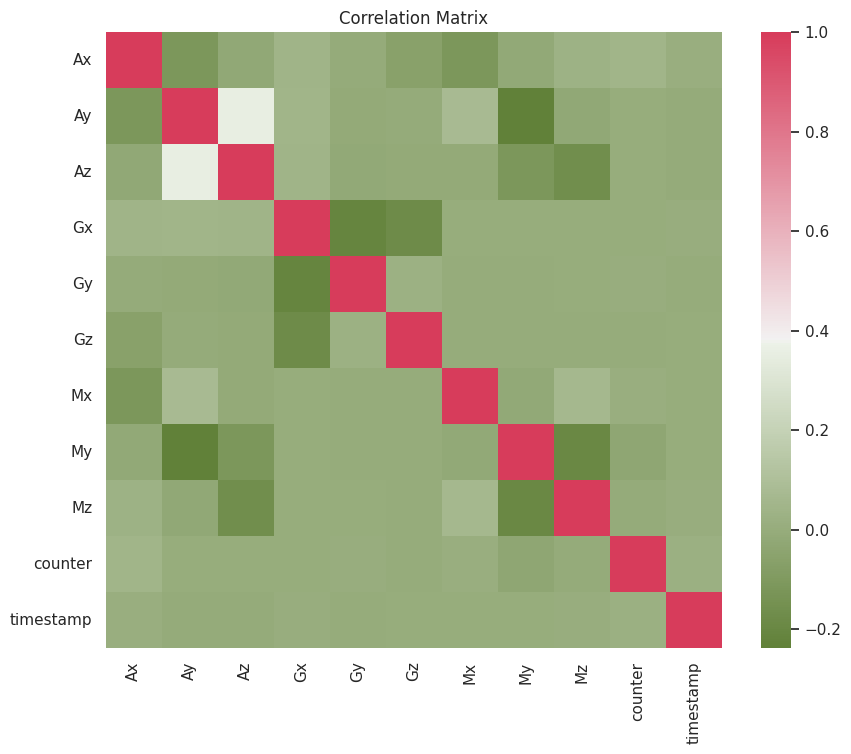

In [73]:
# Correlation matrix
CorrInfo = pd.DataFrame(df,columns=["Ax","Ay","Az","Gx","Gy","Gz","Mx","My","Mz","counter", "timestamp"])

f, ax = plt.subplots(figsize=(10, 8))
corr = CorrInfo.corr()
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=bool), cmap=sns.diverging_palette(110, 5, as_cmap=True),
            square=True, ax=ax)
plt.title("Correlation Matrix")

In [74]:
#Square root of sum of squares of accelerometer, linear acceleration and gyroscope data
df["AxGx"] = np.sqrt(np.square(df['Ax']) + np.square(df['Gx']))
df["AxGy"] = np.sqrt(np.square(df['Ax']) + np.square(df['Gy']))
df["AxMy"] = np.sqrt(np.square(df['Ax']) + np.square(df['My']))
df["AxMz"] = np.sqrt(np.square(df['Ax']) + np.square(df['Mz']))
df["Ayz"] = np.sqrt(np.square(df['Ay']) + np.square(df['Az']))
df["AyGx"] = np.sqrt(np.square(df['Ay']) + np.square(df['Gx']))
df["AyGy"] = np.sqrt(np.square(df['Ay']) + np.square(df['Gy']))
df["AyMy"] = np.sqrt(np.square(df['Ay']) + np.square(df['My']))
df["AyMx"] = np.sqrt(np.square(df['Ay']) + np.square(df['Mx']))
df["AyMz"] = np.sqrt(np.square(df['Ay']) + np.square(df['Mz']))
df["AzGx"] = np.sqrt(np.square(df['Az']) + np.square(df['Gx']))
df["AzMx"] = np.sqrt(np.square(df['Az']) + np.square(df['Mx']))
df["Gzy"] = np.sqrt(np.square(df['Gz']) + np.square(df['Gy']) )
df["MxGy"] = np.sqrt(np.square(df['Mx']) + np.square(df['Gy']) )
df["MxGx"] = np.sqrt(np.square(df['Mx']) + np.square(df['Gx']) )
df["MyGy"] = np.sqrt(np.square(df['My']) + np.square(df['Gy']) )
df["MyGx"] = np.sqrt(np.square(df['My']) + np.square(df['Gx']) )
df["Myz"] = np.sqrt(np.square(df['My']) + np.square(df['Mz']))
df["Mxz"] = np.sqrt(np.square(df['Mx']) + np.square(df['Mz']))
df["Mxy"] = np.sqrt(np.square(df['Mx']) + np.square(df['My']))

In [75]:
# Calcular el valor absoluto de la correlación entre todas las columnas y la columna "target"
correlations = df.drop(columns=['deviceId']).corr().stack().sort_values(ascending=False)
#correlations = abs(df.corr()['activity'])

# Ordenar las correlaciones de mayor a menor
correlations = correlations.sort_values(ascending=False)

# Visualizar las correlaciones
print(correlations)

Ax    Ax      1.000000
MxGy  MxGy    1.000000
AyMy  AyMy    1.000000
AyMx  AyMx    1.000000
AyMz  AyMz    1.000000
                ...   
AxGx  Ay     -0.326479
Ay    AyGy   -0.414084
AyGy  Ay     -0.414084
Ay    AyGx   -0.453410
AyGx  Ay     -0.453410
Length: 1156, dtype: float64


# Modelo de Red Neuronal

In [76]:
features = ['Az', 'AyGx','AxGx','AyGy','AxGy','AzGx','Mxz','MyGx','AyMz','Ayz','Mz','Ax','My','Gzy','Ay','MxGx','MxGy','Myz','Mx','Mxy','AyMx','AzMx','AyMy','Gz']

# Verificar duplicados
duplicates = set(x for x in features if features.count(x) > 1)

if duplicates:
    print(f"\nSe encontraron elementos duplicados: {list(duplicates)}")
else:
    print("\nNo hay elementos duplicados.")



No hay elementos duplicados.


In [77]:
import joblib

# Guardar los nombres de las columnas
columnas_guardadas = df[features].columns.tolist()
ruta_columnas = "../../Datos/Columnas/columnas_HAR_UPM_LSTM.pkl"
joblib.dump(columnas_guardadas, ruta_columnas)

['../../Datos/Columnas/columnas_HAR_UPM_LSTM.pkl']

In [78]:
#Para ver la mayor corelación
X_orig = df[features]
y = df['activity']

RANDOM_STATE = 10
numero_de_filas, numero_de_columnas = X_orig.shape

print("Número de filas:", numero_de_filas)
print("Número de columnas:", numero_de_columnas)

Número de filas: 360000
Número de columnas: 24


In [79]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout

# Paso 1: Definir los datos de entrada y las etiquetas
X_orig = df[features]
y = df['activity']

# Paso 2: Separar características y variable objetivo
X = X_orig.to_numpy()

# Paso 3: Codificar etiquetas con LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Paso 4: Codificar etiquetas en formato one-hot
onehot_encoder = OneHotEncoder(sparse=False)
y_onehot = onehot_encoder.fit_transform(y_encoded.reshape(-1, 1))

# Paso 5: Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Paso 6: Ajustar forma de los datos para LSTM y convertir a tipo float
X_train = X_train.astype(float)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.astype(float)
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Paso 7: Crear modelo LSTM
model = Sequential()
#model.add(LSTM(256, input_shape=(1, X_train.shape[2])))
#model.add(Dropout(0.2))
#model.add(Dense(6, activation='softmax'))
#--------------------------------------------
model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
#model.add(Dropout(0.2))
model.add(LSTM(128))
#model.add(Dropout(0.2))
model.add(Dense(6, activation='softmax'))
#--------------------------------------------
#model.add(LSTM(128, input_shape=(1, X_train.shape[2])))
#model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
#model.add(LSTM(128))
#model.add(Dense(64, activation='relu'))  # Capa Dense adicional
#model.add(Dense(32, activation='relu'))  # Otra capa Dense
#model.add(Dense(6, activation='softmax'))
#------------------------------------------------
#model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la primera capa LSTM
#model.add(LSTM(128))
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la segunda capa LSTM
#model.add(Dense(64, activation='relu'))  # Capa Dense adicional
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la capa Dense adicional
#model.add(Dense(32, activation='relu'))  # Otra capa Dense adicional
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la otra capa Dense adicional
#model.add(Dense(6, activation='softmax'))


# Paso 8: Compilar y entrenar modelo LSTM
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))


2026-08-13 15:25:31.236847: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-13 15:25:31.240605: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-13 15:25:31.289150: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-13 15:25:31.291164: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-13 15:25:32.127837: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

Epoch 1/20
4500/4500 [==============================] - 41s 9ms/step - loss: 0.7021 - accuracy: 0.7456 - val_loss: 0.5640 - val_accuracy: 0.8018
Epoch 2/20
4500/4500 [==============================] - 37s 8ms/step - loss: 0.5144 - accuracy: 0.8176 - val_loss: 0.4880 - val_accuracy: 0.8265
Epoch 3/20
4500/4500 [==============================] - 38s 9ms/step - loss: 0.4521 - accuracy: 0.8397 - val_loss: 0.4410 - val_accuracy: 0.8463
Epoch 4/20
4500/4500 [==============================] - 37s 8ms/step - loss: 0.4103 - accuracy: 0.8546 - val_loss: 0.4049 - val_accuracy: 0.8591
Epoch 5/20
4500/4500 [==============================] - 38s 8ms/step - loss: 0.3816 - accuracy: 0.8638 - val_loss: 0.3802 - val_accuracy: 0.8667
Epoch 6/20
4500/4500 [==============================] - 39s 9ms/step - loss: 0.3617 - accuracy: 0.8710 - val_loss: 0.3617 - val_accuracy: 0.8715
Epoch 7/20
4500/4500 [==============================] - 40s 9ms/step - loss: 0.3459 - accuracy: 0.8771 - val_loss: 0.3652 - val_ac

In [80]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Realizar las predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)

# Decodificar las etiquetas reales
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación
accuracy = np.mean(y_pred_labels_decoded == y_test_labels_decoded)
precision = precision_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
recall = recall_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
f1 = f1_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')

# Imprimir los resultados
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

2250/2250 [==============================] - 8s 3ms/step
Accuracy: 0.9007222222222222
Precision: 0.9024852782589253
Recall: 0.9007222222222222
F1 Score: 0.9014459106536207


/home/rclozano/TFM_HAR/tf_env.venv/lib/python3.8/site-packages/sklearn/preprocessing/_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Labels=['Caminar', 'Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']

# Realizar las predicciones en el conjunto de prueba
y_pred_probabilities = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probabilities, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas y reales
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación para cada etiqueta
num_labels = len(label_encoder.classes_)
accuracy_per_label = []
precision_per_label = []
recall_per_label = []
f1_per_label = []

for label_idx in range(num_labels):
    y_true_label = (y_test_labels_decoded == label_encoder.classes_[label_idx]).astype(int)
    y_pred_label = (y_pred_labels_decoded == label_encoder.classes_[label_idx]).astype(int)

    accuracy_per_label.append(accuracy_score(y_true_label, y_pred_label))
    precision_per_label.append(precision_score(y_true_label, y_pred_label))
    recall_per_label.append(recall_score(y_true_label, y_pred_label))
    f1_per_label.append(f1_score(y_true_label, y_pred_label))

# Imprimir los resultados por etiqueta
for label_idx in range(num_labels):
    print(f'Label: {label_encoder.classes_[label_idx]}, {Labels[label_idx]}')
    print('Accuracy:', accuracy_per_label[label_idx])
    print('Precision:', precision_per_label[label_idx])
    print('Recall:', recall_per_label[label_idx])
    print('F1 Score:', f1_per_label[label_idx])
    print()

   1/2250 [..............................] - ETA: 47s

2250/2250 [==============================] - 8s 3ms/step


/home/rclozano/TFM_HAR/tf_env.venv/lib/python3.8/site-packages/sklearn/preprocessing/_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Label: 1, Caminar
Accuracy: 0.9396666666666667
Precision: 0.814672131147541
Recall: 0.826734320412577
F1 Score: 0.82065890512757

Label: 2, Metro
Accuracy: 0.9748055555555556
Precision: 0.933782745968086
Recall: 0.9133628244720808
F1 Score: 0.9234599156118143

Label: 3, Bus
Accuracy: 0.9789027777777778
Precision: 0.9408469829415259
Recall: 0.9309707759489418
F1 Score: 0.9358828247013633

Label: 4, Conducir coche
Accuracy: 0.9907777777777778
Precision: 0.9760858543180666
Recall: 0.9680690579953067
F1 Score: 0.972060927375242

Label: 5, Subir o bajar escaleras
Accuracy: 0.9352222222222222
Precision: 0.7913555992141453
Recall: 0.8336782846262107
F1 Score: 0.8119658119658119

Label: 6, Estar detenido
Accuracy: 0.9820694444444444
Precision: 0.9594514013118665
Recall: 0.932521940718662
F1 Score: 0.9457950203636059



## Matriz de confusión

<function matplotlib.pyplot.show(close=None, block=None)>

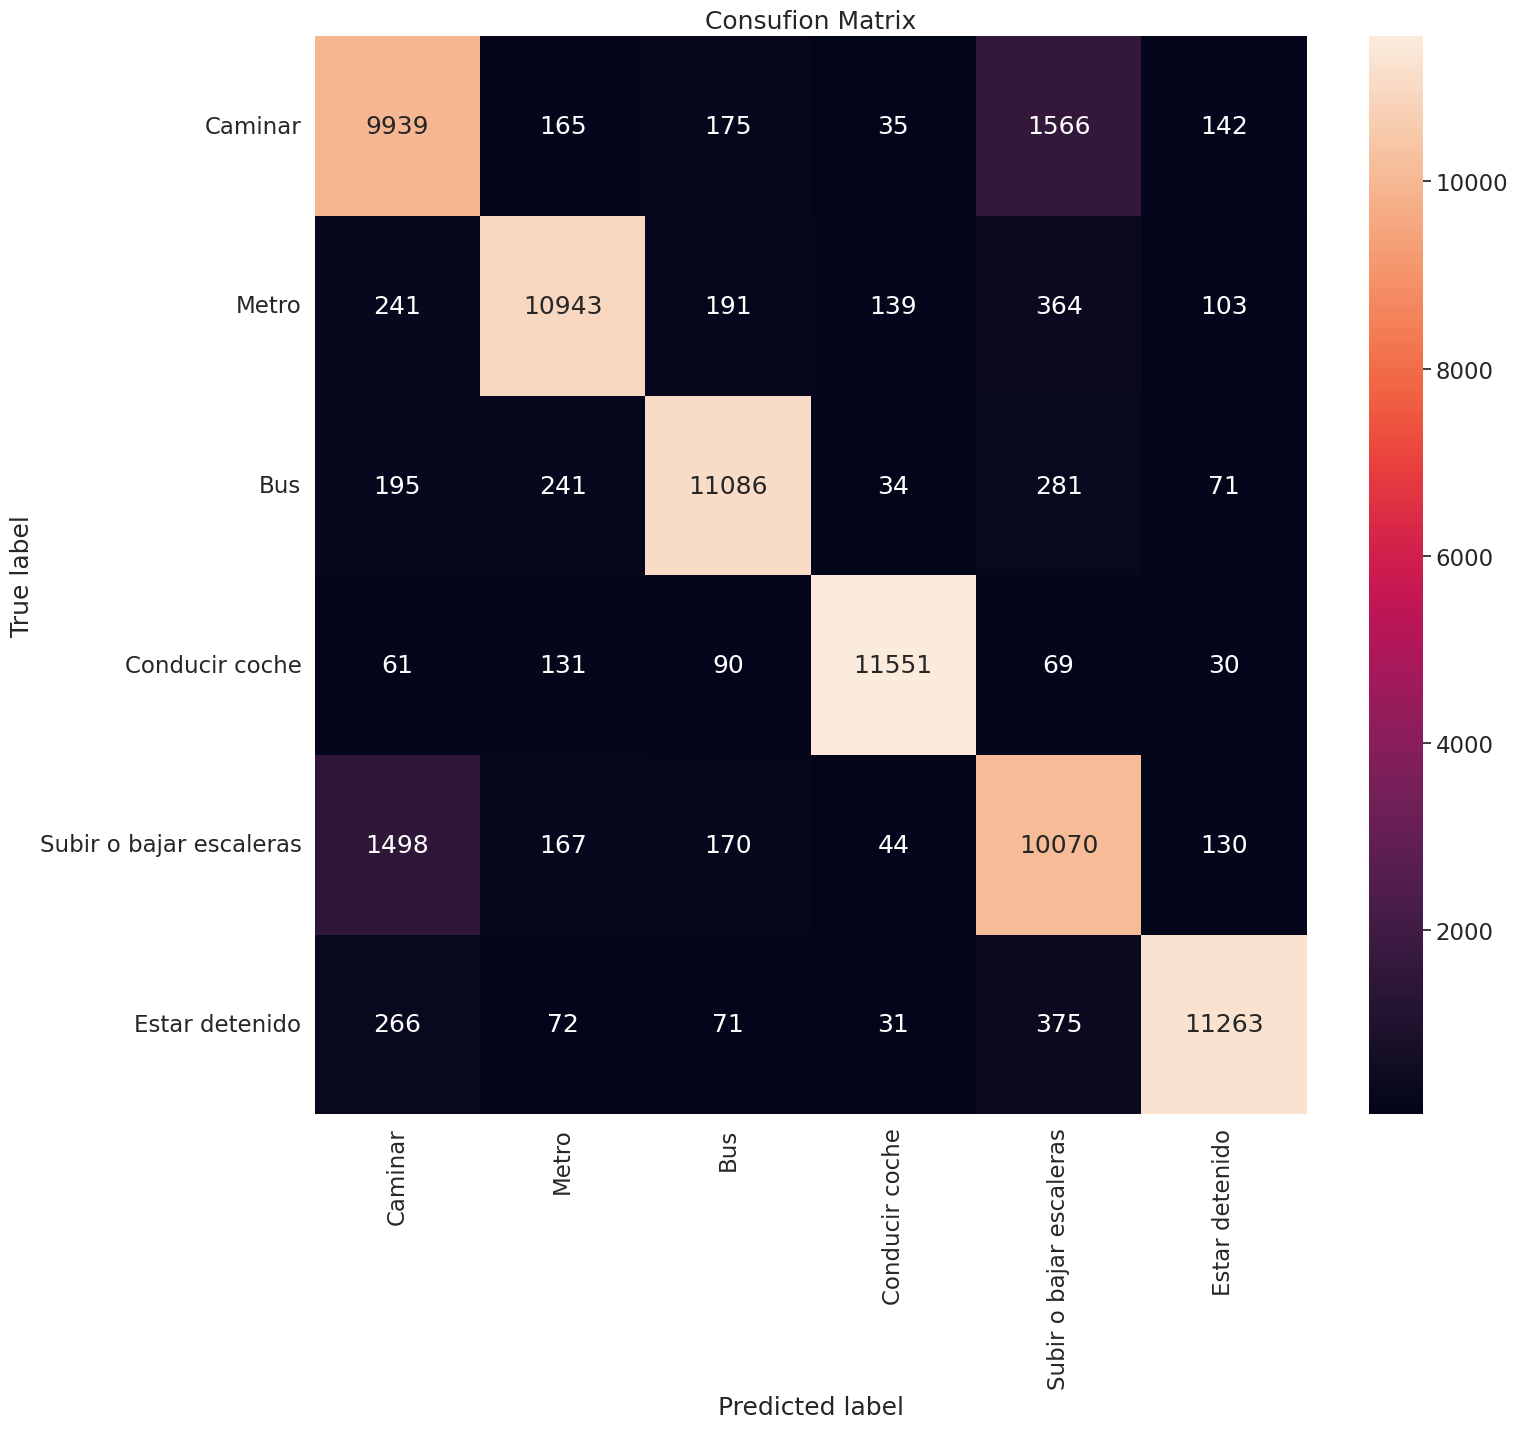

In [82]:
confusion_matrix = metrics.confusion_matrix(y_true=y_true_labels, y_pred=y_pred_labels)

#Labels=['Caminar', 'Metro', 'Conducir coche', 'Subir o bajar escaleras']
#Labels=['Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']
Labels=['Caminar', 'Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']
#Labels=['Metro', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']

plt.figure(figsize=(16,14))
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
sns.heatmap(confusion_matrix, xticklabels=Labels, yticklabels=Labels, annot=True,fmt='d')
plt.title('Consufion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show


In [83]:
# Obtener los valores únicos y sus conteos
valores, conteos = np.unique(y_true_labels, return_counts=True)

#Imprimir el resultado
for valor, conteo, label in zip(valores, conteos, Labels):
    print(f"Valor: {valor}, Cantidad: {conteo}, Actividad: {label}")

Valor: 0, Cantidad: 12022, Actividad: Caminar
Valor: 1, Cantidad: 11981, Actividad: Metro
Valor: 2, Cantidad: 11908, Actividad: Bus
Valor: 3, Cantidad: 11932, Actividad: Conducir coche
Valor: 4, Cantidad: 12079, Actividad: Subir o bajar escaleras
Valor: 5, Cantidad: 12078, Actividad: Estar detenido


# Exportamos el modelo

In [84]:
model.save('../../Datos/Modelos/model.h5')

/home/rclozano/TFM_HAR/tf_env.venv/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [85]:
import joblib
# Ruta donde se guardará la información del modelo
ruta_info_modelo = "../../Datos/Info/info_modelo_HAR_UPM_LSTM.pkl"
info_modelo = {
    'columnas': columnas_guardadas,
    'input_names': model.input_names,
    'output_names': model.output_names
}
joblib.dump(info_modelo, ruta_info_modelo)

# Ruta donde se guardará el modelo
ruta_modelo = "../../Datos/Modelos/model_HAR_UPM_LSTM"
model.save(ruta_modelo)

# Ruta donde se guardará el LabelEncoder
ruta_label_encoder = "../../Datos/Label/label_encoder_HAR_UPM_LSTM.pkl"
joblib.dump(label_encoder, ruta_label_encoder)



INFO:tensorflow:Assets written to: ../../Datos/Modelos/model_HAR_UPM_LSTM/assets


INFO:tensorflow:Assets written to: ../../Datos/Modelos/model_HAR_UPM_LSTM/assets


['../../Datos/Label/label_encoder_HAR_UPM_LSTM.pkl']

In [86]:
# Save the model in TensorFlow.js Layers format
model.save('../../Datos/Modelos/model_HAR_UPM_LSTM/model.json')


INFO:tensorflow:Assets written to: ../../Datos/Modelos/model_HAR_UPM_LSTM/model.json/assets


INFO:tensorflow:Assets written to: ../../Datos/Modelos/model_HAR_UPM_LSTM/model.json/assets


In [87]:
import tensorflow as tf

# Guardar el modelo en formato SavedModel
model.save("../../Datos/Modelos/saved_model", save_format='tf')

INFO:tensorflow:Assets written to: ../../Datos/Modelos/saved_model/assets


INFO:tensorflow:Assets written to: ../../Datos/Modelos/saved_model/assets


In [88]:
import tensorflow as tf

# Ruta donde guardaste tu modelo SavedModel
ruta_modelo = "../../Datos/Modelos/model_HAR_UPM_LSTM"
ruta_label_encoder = "../../Datos/Label/label_encoder_HAR_UPM_LSTM.pkl"

# Cargar la información del modelo y el LabelEncoder
info_modelo_cargado = joblib.load(ruta_info_modelo)
modelo_cargado = tf.keras.models.load_model(ruta_modelo)
label_encoder_cargado = joblib.load(ruta_label_encoder)


In [89]:
# Obtener información sobre las entradas y salidas del modelo
print("Entradas del Modelo:")
for nombre_entrada, tensor_entrada in zip(modelo_cargado.input_names, modelo_cargado.inputs):
    print(f"Nombre: {nombre_entrada}, Forma: {tensor_entrada.shape}, Tipo de Dato: {tensor_entrada.dtype}")

print("\nSalidas del Modelo:")
for nombre_salida, tensor_salida in zip(modelo_cargado.output_names, modelo_cargado.outputs):
    print(f"Nombre: {nombre_salida}, Forma: {tensor_salida.shape}, Tipo de Dato: {tensor_salida.dtype}")


Entradas del Modelo:
Nombre: lstm_input, Forma: (None, 1, 24), Tipo de Dato: <dtype: 'float32'>

Salidas del Modelo:
Nombre: dense, Forma: (None, 6), Tipo de Dato: <dtype: 'float32'>


In [90]:
# Elegir un índice específico para la predicción (por ejemplo, el primero)
indice_prediccion = 5000
y_pred_probabilidades_actividad_especifica = model.predict(X_test[indice_prediccion:indice_prediccion + 1])
y_pred_actividad_especifica_confianza = np.max(y_pred_probabilidades_actividad_especifica)  # Obtener la confianza asociada con la predicción


# Imprimir las probabilidades para la actividad específica
print('Probabilidades para la Predicción:')
print(y_pred_probabilidades_actividad_especifica)

# Imprimir los resultados para la actividad específica
print(f'Confianza para la Predicción: {y_pred_actividad_especifica_confianza * 100:.2f}%')


1/1 [==============================] - 1s 513ms/step
Probabilidades para la Predicción:
[[1.32475915e-08 2.65148481e-09 2.52441534e-09 3.40616309e-14
  9.06539732e-10 1.00000000e+00]]
Confianza para la Predicción: 100.00%


# Modelo Tflite

In [91]:
import tensorflow as tf
import joblib

# Carga el modelo y la información necesaria
model = tf.keras.models.load_model("../../Datos/Modelos/model_HAR_UPM_LSTM")
label_encoder = joblib.load("../../Datos/Label/label_encoder_HAR_UPM_LSTM.pkl")
columnas_guardadas = joblib.load("../../Datos/Info/info_modelo_HAR_UPM_LSTM.pkl")['columnas']

# Convierte el modelo a formato TFLite con configuración específica
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter.experimental_new_converter = True
tflite_model = converter.convert()

# Ruta donde se guardará el modelo TFLite
ruta_modelo_tflite = "../../Datos/Modelos/model_HAR_UPM_LSTM.tflite"

# Guarda el modelo TFLite en el archivo
with open(ruta_modelo_tflite, 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpb5g3w9eb/assets


INFO:tensorflow:Assets written to: /tmp/tmpb5g3w9eb/assets
2026-08-13 15:39:16.076327: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-08-13 15:39:16.076360: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-08-13 15:39:16.077022: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpb5g3w9eb
2026-08-13 15:39:16.090188: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-08-13 15:39:16.090211: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmpb5g3w9eb
2026-08-13 15:39:16.139133: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:375] MLIR V1 optimization pass is not enabled
2026-08-13 15:39:16.148144: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-08-13 15:39:16.241213: I tensorflow/cc/saved_model/loader.cc:215] Running initializatio

In [92]:
ruta2_archivo_csv = "../../Datos/sensor_data2.csv"

df2 = pd.read_csv(ruta2_archivo_csv)

columnas_deseadas = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ", "MagX", "MagY", "MagZ", "Timestamp"]  # Cambia los nombres de las columnas según tus necesidades
df2 = df2.reindex(columns=columnas_deseadas)

print(df2)

         AccX      AccY      AccZ     GyroX     GyroY     GyroZ     MagX  \
0   -0.561715 -0.037986  9.846166  0.000611 -0.001909  0.000153 -4.42500   
1   -0.553639 -0.042473  9.855139  0.000382 -0.001680  0.000153 -4.20000   
2   -0.562313 -0.039781  9.857233  0.000458 -0.001603  0.000153 -4.10625   
3   -0.563211 -0.038883  9.858429  0.000534 -0.001909  0.000153 -4.10625   
4   -0.559921 -0.040678  9.855438  0.000611 -0.001833  0.000229 -4.10625   
..        ...       ...       ...       ...       ...       ...      ...   
141 -0.563510 -0.046959  9.864411  0.000611 -0.001145 -0.000153 -3.97500   
142 -0.553340 -0.040379  9.866505  0.000458 -0.001222 -0.000229 -3.97500   
143 -0.565005 -0.038883  9.865009  0.000458 -0.001222  0.000153 -3.93750   
144 -0.554836 -0.042173  9.864711  0.000534 -0.001451 -0.000229 -3.91875   
145 -0.558724 -0.040080  9.867402  0.000458 -0.001222 -0.000229 -3.86250   

          MagY       MagZ      Timestamp  
0   -32.587500 -22.668750  1707067580367  
1

In [93]:
# Nuevos nombres de columnas
nuevos_nombres = ["Ax", "Ay", "Az", "Gx", "Gy", "Gz", "Mx", "My", "Mz", "timestamp"]  # Cambia los nombres de las columnas según tus necesidades

# Asignar los nuevos nombres de columnas
df2.columns = nuevos_nombres

In [94]:
# Factor de conversión de m/s^2 a g
g_conversion = 1 / 9.81
# Convertir las columnas Ax, Ay, Az de m/s^2 a g
df2['Ax'] = df2['Ax'] * g_conversion
df2['Ay'] = df2['Ay'] * g_conversion
df2['Az'] = df2['Az'] * g_conversion

# Aplicar la conversión solo a las columnas seleccionadas
columnas=["Gx", "Gy", "Gz"]
df2[columnas] = df2[columnas].apply(np.degrees)

In [95]:
df2.head(50)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,timestamp
0,-0.057259,-0.003872,1.003687,0.034999,-0.109372,0.008750,-4.42500,-32.587500,-22.668750,1707067580367
1,-0.056436,-0.004330,1.004601,0.021874,-0.096247,0.008750,-4.20000,-32.475002,-22.650002,1707067580565
2,-0.057320,-0.004055,1.004815,0.026249,-0.091872,0.008750,-4.10625,-32.493750,-22.593750,1707067580765
3,-0.057412,-0.003964,1.004937,0.030624,-0.109372,0.008750,-4.10625,-32.737503,-22.575000,1707067580965
4,-0.057077,-0.004147,1.004632,0.034999,-0.104997,0.013125,-4.10625,-32.718750,-22.500000,1707067581165
5,-0.057077,-0.003994,1.005333,0.021874,-0.087497,0.026249,-4.06875,-32.362503,-22.575000,1707067581367
6,-0.056741,-0.004269,1.004845,0.030624,-0.104997,0.004375,-4.06875,-32.306250,-22.556252,1707067581569
7,-0.056680,-0.003903,1.004632,0.034999,-0.091872,0.026249,-4.05000,-32.287502,-22.500000,1707067581771
8,-0.057290,-0.003842,1.004937,0.021874,-0.052498,0.048124,-3.99375,-32.100002,-22.443750,1707067581974
9,-0.057229,-0.003933,1.005150,0.026249,-0.083123,0.008750,-3.97500,-31.931252,-22.481250,1707067582176


In [96]:
#Square root of sum of squares of accelerometer, linear acceleration and gyroscope data
df2["AxMy"] = np.sqrt(np.square(df2['Ax']) + np.square(df2['My']))
df2["AxGy"] = np.sqrt(np.square(df2['Ax']) + np.square(df2['Gy']))
df2["Ayz"] = np.sqrt(np.square(df2['Ay']) + np.square(df2['Az']))
df2["AxGx"] = np.sqrt(np.square(df2['Ax']) + np.square(df2['Gx']))
df2["AxGy"] = np.sqrt(np.square(df2['Ax']) + np.square(df2['Gy']))
df2["AyGx"] = np.sqrt(np.square(df2['Ay']) + np.square(df2['Gx']))
df2["AyGy"] = np.sqrt(np.square(df2['Ay']) + np.square(df2['Gy']))
df2["AyMy"] = np.sqrt(np.square(df2['Ay']) + np.square(df2['My']))
df2["AyMx"] = np.sqrt(np.square(df2['Ay']) + np.square(df2['Mx']))
df2["AyMz"] = np.sqrt(np.square(df2['Ay']) + np.square(df2['Mz']))
df2["AzGx"] = np.sqrt(np.square(df2['Az']) + np.square(df2['Gx']))
df2["AzMx"] = np.sqrt(np.square(df2['Az']) + np.square(df2['Mx']))
df2["Gzy"] = np.sqrt(np.square(df2['Gz']) + np.square(df2['Gy']) )
df2["MxGy"] = np.sqrt(np.square(df2['Mx']) + np.square(df2['Gy']) )
df2["MxGx"] = np.sqrt(np.square(df2['Mx']) + np.square(df2['Gx']) )
df2["MyGy"] = np.sqrt(np.square(df2['My']) + np.square(df2['Gy']) )
df2["MyGx"] = np.sqrt(np.square(df2['My']) + np.square(df2['Gx']) )
df2["Myz"] = np.sqrt(np.square(df2['My']) + np.square(df2['Mz']))
df2["Mxz"] = np.sqrt(np.square(df2['Mx']) + np.square(df2['Mz']))
df2["Mxy"] = np.sqrt(np.square(df2['Mx']) + np.square(df2['My']))

In [97]:
features = ['Az', 'AyGx','AxGx','AyGy','AxGy','AzGx','Mxz','MyGx','AyMz','Ayz','Mz','Ax','My','Gzy','Ay','MxGx','MxGy','Myz','Mx','Mxy','AyMx','AzMx','AyMy','Gz']
#Para ver la mayor corelación
X2_orig = df2[features]

In [98]:
X2_orig.head(50)

,Az,AyGx,AxGx,AyGy,AxGy,AzGx,Mxz,MyGx,AyMz,Ayz,...,Ay,MxGx,MxGy,Myz,Mx,Mxy,AyMx,AzMx,AyMy,Gz
0,1.003687,0.035213,0.067109,0.109440,0.123454,1.004297,23.096598,32.587519,22.668750,1.003694,...,-0.003872,4.425138,4.426351,39.696566,-4.42500,32.886559,4.425002,4.537401,32.587500,0.008750
1,1.004601,0.022299,0.060527,0.096344,0.111573,1.004839,23.036115,32.475009,22.650002,1.004611,...,-0.004330,4.200057,4.201103,39.593539,-4.20000,32.745469,4.200003,4.318475,32.475002,0.008750
2,1.004815,0.026561,0.063045,0.091962,0.108287,1.005158,22.963859,32.493761,22.593750,1.004823,...,-0.004055,4.106334,4.107278,39.576778,-4.10625,32.752177,4.106252,4.227404,32.493750,0.008750
3,1.004937,0.030880,0.065069,0.109444,0.123525,1.005403,22.945412,32.737517,22.575000,1.004945,...,-0.003964,4.106364,4.107707,39.766503,-4.10625,32.994021,4.106252,4.227433,32.737503,0.008750
4,1.004632,0.035244,0.066953,0.105079,0.119508,1.005241,22.871626,32.718769,22.500000,1.004640,...,-0.004147,4.106399,4.107592,39.708521,-4.10625,32.975413,4.106252,4.227360,32.718750,0.013125
5,1.005333,0.022236,0.061125,0.087589,0.104468,1.005571,22.938730,32.362510,22.575000,1.005341,...,-0.003994,4.068809,4.069691,39.458361,-4.06875,32.617270,4.068752,4.191113,32.362503,0.026249
6,1.004845,0.030920,0.064478,0.105084,0.119348,1.005312,22.920280,32.306265,22.556252,1.004854,...,-0.004269,4.068866,4.070105,39.401501,-4.06875,32.561458,4.068753,4.190996,32.306250,0.004375
7,1.004632,0.035216,0.066615,0.091955,0.107950,1.005241,22.861594,32.287521,22.500000,1.004639,...,-0.003903,4.050151,4.051042,39.353942,-4.05000,32.540518,4.050002,4.172743,32.287502,0.026249
8,1.004937,0.022209,0.061324,0.052639,0.077706,1.005175,22.796314,32.100009,22.443750,1.004944,...,-0.003842,3.993810,3.994095,39.167998,-3.99375,32.347491,3.993752,4.118244,32.100002,0.048124
9,1.005150,0.026542,0.062962,0.083216,0.100918,1.005493,22.829963,31.931263,22.481250,1.005158,...,-0.003933,3.975087,3.975869,39.051395,-3.97500,32.177717,3.975002,4.100116,31.931252,0.008750


In [99]:
X_orig.head(20)

,Az,AyGx,AxGx,AyGy,AxGy,AzGx,Mxz,MyGx,AyMz,Ayz,...,Ay,MxGx,MxGy,Myz,Mx,Mxy,AyMx,AzMx,AyMy,Gz
5537,0.715030,1.002611,1.194972,1.102986,1.280355,1.226572,40.434829,41.355760,17.812837,0.723385,...,0.109625,36.313681,36.316591,45.017672,-36.300003,55.018141,36.300169,36.307045,41.343895,-0.136263
38238,0.085656,1.366283,1.446639,0.125304,0.491666,1.368196,19.616274,17.808679,8.456375,0.097173,...,0.045887,17.752596,17.700385,19.667043,17.700001,25.071387,17.700060,17.700208,17.756310,-0.955487
53436,-0.399525,0.814505,0.869512,0.698339,0.761781,0.623680,32.308052,8.001845,13.815718,0.770507,...,-0.658834,29.216427,29.213419,15.944910,-29.212502,30.284821,29.219930,29.215233,8.014625,-0.205425
54638,-0.557270,0.510521,0.460388,1.707753,1.693442,0.635329,23.323260,39.544928,23.047386,0.691439,...,-0.409314,3.612907,3.963443,45.768140,3.600000,39.707282,3.623195,3.642877,39.545869,-0.136263
13960,-0.057818,1.098923,0.946052,1.622413,1.523025,0.945707,98.469503,9.105311,88.689285,0.565647,...,-0.562685,42.797913,42.814553,89.148687,-42.787502,43.735409,42.791202,42.787541,9.073714,-0.960850
35094,1.036241,1.231274,0.614883,1.333542,0.800237,1.042223,35.395335,0.463611,35.299430,1.605427,...,-1.226214,2.880285,2.925464,35.280996,-2.878125,2.913092,3.128451,3.058987,1.306178,-0.043725
32323,-0.383112,0.813538,0.805975,0.922159,0.915494,0.606130,36.877777,13.564385,29.594957,0.766812,...,-0.664248,22.017511,22.021792,32.545233,-22.012501,25.851927,22.022521,22.015834,13.572515,1.248225
837,0.290114,0.747916,1.110011,1.560495,1.762920,0.716922,29.647516,28.020171,17.816137,0.462313,...,-0.359955,23.709067,23.748592,33.196165,-23.700001,36.693191,23.702734,23.701776,28.014813,-0.339487
21011,0.040870,1.094295,1.859505,1.133801,1.883025,0.685597,33.888970,0.684635,14.107116,0.854856,...,-0.853878,30.832597,30.834025,14.081263,-30.825001,30.825006,30.836825,30.825028,0.854084,-0.324360
58320,-0.326518,2.090220,1.691493,1.521555,0.898477,1.683751,25.791340,22.504451,24.090327,1.321829,...,-1.280866,9.445550,9.336194,32.900231,9.300000,24.294278,9.387791,9.305730,22.480270,-0.146987


In [100]:
import tensorflow as tf
import numpy as np
import pandas as pd

# Cargar el modelo TFLite
interpreter = tf.lite.Interpreter(model_path="../../Datos/Modelos/model_HAR_UPM_LSTM.tflite")
interpreter.allocate_tensors()

# Obtener detalles de entrada y salida del modelo TFLite
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Definir las columnas de entrada
input_columns = ['Az', 'AyGx', 'AxGx', 'AyGy', 'AxGy', 'AzGx', 'Mxz', 'MyGx', 'AyMz', 'Ayz', 'Mz', 'Ax', 'My', 'Gzy', 'Ay', 'MxGx', 'MxGy', 'Myz', 'Mx', 'Mxy', 'AyMx', 'AzMx', 'AyMy', 'Gz']

# Crear un DataFrame de ejemplo (sustituir con tus datos reales)
data = np.random.randn(10, len(input_columns))  # 10 filas
df2 = pd.DataFrame(data, columns=input_columns)

# Listas para almacenar las predicciones y porcentajes de cada fila
predicted_classes = []
confidence_percentages_list = []

# Iterar sobre todas las filas y realizar inferencia para cada una
for index, row in df2.iterrows():
    # Ajustar forma de los datos para LSTM
    X_inference = row.values.astype(np.float32)
    X_inference = X_inference.reshape((1, 1, len(input_columns)))

    # Verificar si la forma es la esperada
    if X_inference.shape[1:] != tuple(input_details[0]['shape'][1:]):
        raise ValueError(f"La forma del tensor de entrada no coincide con la esperada. Se esperaba {tuple(input_details[0]['shape'])} pero se obtuvo {X_inference.shape}")

    # Realizar inferencia en el modelo TFLite con datos preprocesados
    interpreter.set_tensor(input_details[0]['index'], X_inference)
    interpreter.invoke()
    output_data_tflite = interpreter.get_tensor(output_details[0]['index'])

    # Obtener la clase predicha (índice con la probabilidad más alta)
    predicted_class_index = np.argmax(output_data_tflite) + 1  # Sumar 1 para obtener clases de 1 a 6
    
    # Obtener porcentajes de confianza para cada clase
    confidence_percentages = output_data_tflite[0]

    # Almacenar predicción y porcentajes en listas
    predicted_classes.append(predicted_class_index)
    confidence_percentages_list.append(confidence_percentages)

    # Imprimir los resultados de la inferencia con el modelo TFLite para cada fila
    print(f"\nInput shape para fila {index}:", X_inference.shape)
    print("Output shape (TFLite):", output_data_tflite.shape)
    print("Clase predicha (TFLite):", predicted_class_index)
    print("Porcentajes de confianza:", confidence_percentages)

# Calcular la media de las predicciones y determinar la clase con mayor coincidencia
average_predicted_class = int(round(np.mean(predicted_classes)))
print(f"\nClase con mayor coincidencia (promedio): {average_predicted_class}")

# Calcular la media de los porcentajes de confianza para cada clase
average_confidence_percentages = np.mean(confidence_percentages_list, axis=0)
print("Porcentajes promedio de confianza para cada clase:", average_confidence_percentages)

# Definir la función softmax para normalizar las probabilidades
def softmax(x):
    """Calcula la función softmax para un array."""
    exp_x = np.exp(x - np.max(x))
    return exp_x / exp_x.sum(axis=0, keepdims=True)

# Aplicar softmax a las probabilidades de cada clase
normalized_confidence_percentages_list = [softmax(confidence_percentages) for confidence_percentages in confidence_percentages_list]

# Imprimir los porcentajes de confianza normalizados
print("\nPorcentajes de confianza normalizados:")
for i, normalized_confidence_percentages in enumerate(normalized_confidence_percentages_list):
    print(f"Fila {i}:", normalized_confidence_percentages)

# Calcular la media de los porcentajes de confianza normalizados para cada clase
average_normalized_confidence_percentages = np.mean(normalized_confidence_percentages_list, axis=0)
print("\nPorcentajes promedio de confianza normalizados para cada clase:", average_normalized_confidence_percentages)




Input shape para fila 0: (1, 1, 24)
Output shape (TFLite): (1, 6)
Clase predicha (TFLite): 6
Porcentajes de confianza: [4.3550948e-14 3.5976488e-16 5.2147284e-12 2.6529769e-13 2.6520561e-13
 1.0000000e+00]

Input shape para fila 1: (1, 1, 24)
Output shape (TFLite): (1, 6)
Clase predicha (TFLite): 3
Porcentajes de confianza: [6.8692984e-03 3.4903027e-05 9.5271957e-01 3.7327409e-06 2.3771536e-02
 1.6601000e-02]

Input shape para fila 2: (1, 1, 24)
Output shape (TFLite): (1, 6)
Clase predicha (TFLite): 2
Porcentajes de confianza: [3.1917295e-07 9.1201049e-01 5.8147038e-05 3.7815914e-04 1.2497658e-05
 8.7540358e-02]

Input shape para fila 3: (1, 1, 24)
Output shape (TFLite): (1, 6)
Clase predicha (TFLite): 3
Porcentajes de confianza: [1.3908727e-06 6.7448798e-03 8.8077354e-01 1.1021152e-01 8.4606554e-06
 2.2601029e-03]

Input shape para fila 4: (1, 1, 24)
Output shape (TFLite): (1, 6)
Clase predicha (TFLite): 5
Porcentajes de confianza: [2.9602030e-04 8.4346830e-06 4.2308695e-03 3.8352708

INFO: Created TensorFlow Lite delegate for select TF ops.
2026-08-13 15:39:16.960016: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
INFO: TfLiteFlexDelegate delegate: 4 nodes delegated out of 21 nodes with 3 partitions.

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [101]:
# Obtener detalles de entrada del modelo TFLite
input_details = interpreter.get_input_details()

# Imprimir la forma esperada para el tensor de entrada
print("Expected input shape:", input_details[0]['shape'])


Expected input shape: [ 1  1 24]


In [102]:
import tensorflow as tf
import numpy as np

# Carga el modelo TFLite
interpreter = tf.lite.Interpreter(model_path="../../Datos/Modelos/model_HAR_UPM_LSTM.tflite")
interpreter.allocate_tensors()

# Obtén los detalles de la entrada y salida del modelo
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Datos de ejemplo para la inferencia (ajústalos según sea necesario)
input_data = np.random.randn(*input_details[0]['shape']).astype(np.float32)

# Realiza la inferencia
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])

# Imprime los resultados
print("Input shape:", input_data.shape)
print("Output shape:", output_data.shape)
print("Inferencia exitosa:", output_data)


Input shape: (1, 1, 24)
Output shape: (1, 6)
Inferencia exitosa: [[0.02637701 0.5470528  0.01569201 0.00134935 0.40859047 0.00093845]]


2026-08-13 15:39:17.252344: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [103]:
import tensorflow as tf
import numpy as np

# Cargar el modelo TFLite
interpreter.allocate_tensors()

# Obtener los detalles de entrada y salida del modelo
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Datos de entrada específicos proporcionados
input_data = np.array([[
    0.812345, 9.776321, 0.0, 13.825807, 9.776321, 0.812345,
    0.812345, 9.776321, 9.776321, 9.776321, 0.812345, 0.0,
    9.776321, 9.810014, 9.776321, 0.0, 9.776321, 9.810014,
    0.0, 9.776321, 9.776321, 0.812345, 9.776321, 0.812345
]], dtype=np.float32)

# Ajustar la forma para que coincida con la esperada por el modelo
input_data = np.reshape(input_data, (input_data.shape[0], 1, input_data.shape[1]))

# Realizar la inferencia
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])

# Imprimir los resultados
print("Input shape:", input_data.shape)
print("Output shape:", output_data.shape)
print("Inferencia exitosa:", output_data)


Input shape: (1, 1, 24)
Output shape: (1, 6)
Inferencia exitosa: [[1.7500688e-04 9.9926215e-01 3.5992508e-07 4.8070925e-09 5.6235085e-04
  1.7773968e-07]]
